[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Boyu-Zhang-UOI/pml-f2026-notebooks/blob/main/02-data-science-stack/04_eda_methodology.ipynb)

# One Table, Four Phases

**Session 6 · no homework depends on this, the project does · run it in order**

The visualization notebook teaches Matplotlib and Seaborn. This one teaches the
order to use them in, because the mistake that costs a project is never a wrong
`figsize`; it is concluding something the picture does not support.

Four phases, in this order, on one table:

1. **what is this table?** rows, columns, units, what one row means
2. **what is in the columns?** distributions, one variable at a time
3. **how do the columns relate?** pairs, and only after conditioning
4. **what cannot be true?** the checks that catch the data being wrong

The reading numbers the same procedure as ten steps. The phases here cover steps
1 to 3, 5, 6 to 7, and 9; this table has no target column, so step 4 does not
arise, and step 8 (grouping structure) is folded into phase 3. The notebook ends
with step 10, the findings note. Before that come two pairs of figures in which
the same correct numbers lead to different conclusions depending on how they are
drawn.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
rng = np.random.default_rng(4)

n = 900
site = rng.choice(["hatchery", "river", "lake"], n, p=[0.42, 0.33, 0.25])
base_len = {"hatchery": 21.0, "river": 27.5, "lake": 33.0}
length_cm = np.array([rng.normal(base_len[s], 2.6) for s in site])
# Mass follows length, but the intercept differs by site: the setting for Simpson's paradox.
mass_g = np.array([rng.normal(9.5 * l - {"hatchery": 60, "river": 105, "lake": 150}[s], 12)
                   for l, s in zip(length_cm, site)])

fish = pd.DataFrame({
    "site": site,
    "sampled_on": pd.to_datetime("2026-05-01") + pd.to_timedelta(rng.integers(0, 120, n), "D"),
    "length_cm": np.round(length_cm, 1),
    "mass_g": np.round(mass_g, 1),
    "tagged": rng.random(n) < 0.35,
})
fish.loc[rng.choice(n, 30, replace=False), "mass_g"] = np.nan
fish.loc[rng.choice(n, 4, replace=False), "length_cm"] = 0.0      # a sensor fault
fish.head()

,site,sampled_on,length_cm,mass_g,tagged
0,lake,2026-05-27,31.9,167.7,False
1,river,2026-08-23,25.5,143.9,False
2,lake,2026-06-17,32.6,161.0,False
3,hatchery,2026-05-29,19.8,130.1,True
4,river,2026-05-01,26.1,128.2,False


## Phase 1: what is this table?

Not a plot. Before anything is drawn, answer three questions in writing: what
does one row represent, what are the units, and what is missing.

In [2]:
print("shape:", fish.shape)
print("\none row is: one fish, measured once, at one site\n")
print(pd.DataFrame({
    "dtype": fish.dtypes.astype(str),
    "missing": fish.isna().sum(),
    "n_unique": fish.nunique(),
}).to_string())
print("\ndate range:", fish.sampled_on.min().date(), "to", fish.sampled_on.max().date())

shape: (900, 5)

one row is: one fish, measured once, at one site

                     dtype  missing  n_unique
site                   str        0         3
sampled_on  datetime64[us]        0       120
length_cm          float64        0       224
mass_g             float64       30       598
tagged                bool        0         2

date range: 2026-05-01 to 2026-08-28


Thirty missing masses, no missing lengths, five columns, one row per fish. That
paragraph is the deliverable of phase 1 and it takes two minutes; skipping it is
how an afternoon goes into plotting a column that turns out to be an identifier.

## Phase 2: what is in the columns?

One variable at a time. A histogram answers "what values occur, and how often",
and the bin width is a choice that changes the answer.

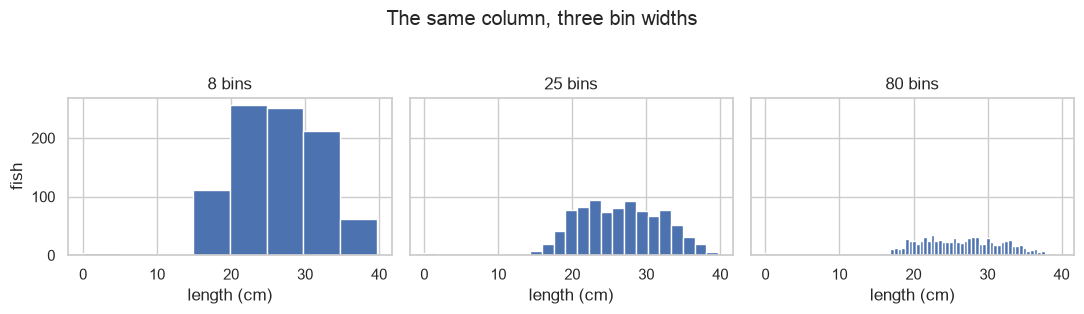

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(11, 3), sharey=True)
for ax, bins in zip(axes, [8, 25, 80]):
    ax.hist(fish.length_cm, bins=bins, color="#4C72B0")
    ax.set_title(f"{bins} bins")
    ax.set_xlabel("length (cm)")
axes[0].set_ylabel("fish")
fig.suptitle("The same column, three bin widths", y=1.04)
fig.tight_layout()
plt.show()

Eight bins hide the structure; eighty show mostly sampling noise. The middle
panel shows what is actually there: not a bell, but a wide flat plateau. A
single population does not look like that, and the reason it does not is phase
3's job to find.

What the histogram does **not** show you is the sensor fault. Four fish are
recorded at 0.0 cm: four counts against bars of fifty, a bar one pixel high at
the far left. Rare impossible values are exactly what a distribution plot is bad
at, which is why phase 4 checks ranges with arithmetic instead of eyes:

In [4]:
impossible = fish.length_cm <= 0
print("impossible lengths:", int(impossible.sum()))
print(fish.loc[impossible, ["site", "length_cm", "mass_g"]].to_string(index=False))

clean = fish.loc[~impossible].copy()
print("\nrows kept:", len(clean), "of", len(fish))

impossible lengths: 4
    site  length_cm  mass_g
   river        0.0   201.2
hatchery        0.0   166.9
    lake        0.0   218.2
hatchery        0.0   141.0

rows kept: 896 of 900


## Phase 3: how do the columns relate?

The scatter of mass against length is the plot everybody draws. Fit a line
through it and you have a number. Condition on site first and you have a
different number, and the difference is the whole reason to condition.

In [5]:
pooled_r = clean[["length_cm", "mass_g"]].corr().iloc[0, 1]
pooled_slope = np.polyfit(clean.dropna(subset=["mass_g"]).length_cm,
                          clean.dropna(subset=["mass_g"]).mass_g, 1)[0]
print(f"pooled over all sites: r = {pooled_r:.3f}   slope = {pooled_slope:.1f} g per cm\n")

for name, group in clean.dropna(subset=["mass_g"]).groupby("site"):
    r = group[["length_cm", "mass_g"]].corr().iloc[0, 1]
    slope = np.polyfit(group.length_cm, group.mass_g, 1)[0]
    print(f"  {name:<9} n = {len(group):>3}   r = {r:.3f}   slope = {slope:.1f} g per cm")

pooled over all sites: r = 0.684   slope = 3.6 g per cm

  hatchery  n = 348   r = 0.905   slope = 9.9 g per cm
  lake      n = 235   r = 0.909   slope = 9.1 g per cm
  river     n = 283   r = 0.876   slope = 9.0 g per cm


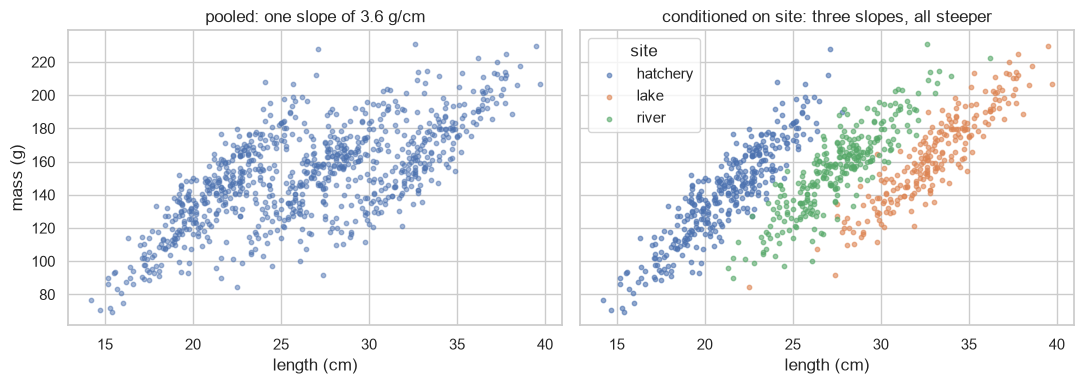

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
sub = clean.dropna(subset=["mass_g"])

axes[0].scatter(sub.length_cm, sub.mass_g, s=10, alpha=.5, color="#4C72B0")
axes[0].set_title(f"pooled: one slope of {pooled_slope:.1f} g/cm")

for name, group in sub.groupby("site"):
    axes[1].scatter(group.length_cm, group.mass_g, s=10, alpha=.6, label=name)
axes[1].set_title("conditioned on site: three slopes, all steeper")
axes[1].legend(title="site")

for ax in axes:
    ax.set_xlabel("length (cm)")
axes[0].set_ylabel("mass (g)")
fig.tight_layout()
plt.show()

Within every site, a centimetre is worth about nine grams. Pooled, it is worth
under four. The pooled number is not a compromise between the three; it is
**less than half** of any of them.

Nothing is wrong with the arithmetic. The sites differ in *both* variables at
once: lake fish are longer, and lake fish are lighter for their length. Pooling
measures the difference between sites and reports it as if it were a
relationship within them, and here the two effects point in opposite directions,
so the relationship is flattened rather than exaggerated. It can go the other
way just as easily, which is the point. You cannot predict the direction of the
error, only avoid making it.

This is Simpson's paradox as the reading defines it: the pooled number describes
the mixture of sites, not any site. The defence is procedural, not statistical:
**before pooling, ask what else differs between the groups you are pooling.**

## Phase 4: what cannot be true?

Range checks, cross-column checks, and a check on the thing you are about to
claim. These are the assertions your reader would make if they were suspicious,
written down before they get the chance.

In [7]:
checks = {
    "no negative or zero lengths": bool((clean.length_cm > 0).all()),
    "no negative masses": bool((clean.mass_g.dropna() > 0).all()),
    "dates inside the sampling season": bool(clean.sampled_on.between("2026-05-01", "2026-09-01").all()),
    "every site has at least 100 fish": bool((clean.site.value_counts() >= 100).all()),
    "mass and length are positively related within every site": bool(all(
        g[["length_cm", "mass_g"]].corr().iloc[0, 1] > 0
        for _, g in clean.dropna(subset=["mass_g"]).groupby("site"))),
}
for name, passed in checks.items():
    print(f"  {'ok  ' if passed else 'FAIL'} {name}")

  ok   no negative or zero lengths
  ok   no negative masses
  ok   dates inside the sampling season
  ok   every site has at least 100 fish
  ok   mass and length are positively related within every site


## Wrong versus right, pair 1: overplotting

Four thousand points in one panel is not four thousand points; it is a shape
whose interior you cannot see. Three remedies, all one keyword. The reading's
third remedy, drawing a random subsample, keeps the grammar of a scatter plot;
the kernel density estimate here is the smoothed relative of the hexbin.

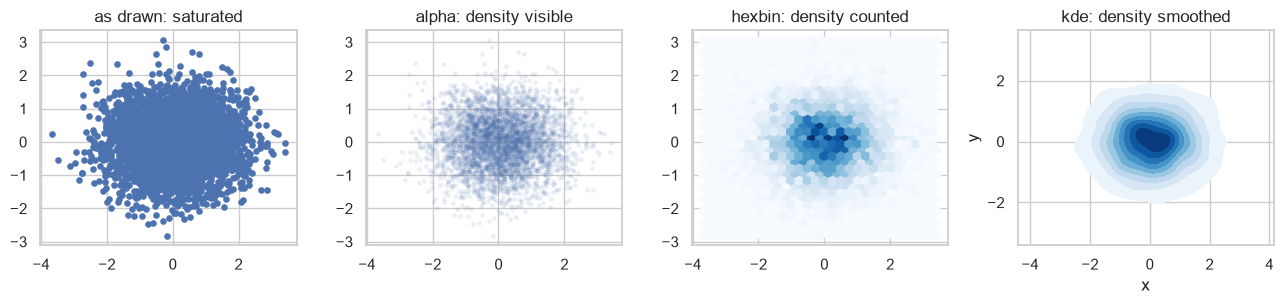

In [8]:
dense = pd.DataFrame({
    "x": rng.normal(size=4000),
    "y": rng.normal(size=4000) * 0.6 + rng.normal(size=4000) * 0.5,
})

fig, axes = plt.subplots(1, 4, figsize=(13, 3.2))
axes[0].scatter(dense.x, dense.y, s=14)
axes[0].set_title("as drawn: saturated")
axes[1].scatter(dense.x, dense.y, s=6, alpha=0.08)
axes[1].set_title("alpha: density visible")
axes[2].hexbin(dense.x, dense.y, gridsize=28, cmap="Blues")
axes[2].set_title("hexbin: density counted")
sns.kdeplot(data=dense, x="x", y="y", fill=True, ax=axes[3], cmap="Blues")
axes[3].set_title("kde: density smoothed")
fig.tight_layout()
plt.show()

The left panel is not *false*. It is simply unable to answer the question
anybody would ask of it, where most of the points are, and the three on the
right answer it without changing a single number.

## Wrong versus right, pair 2: the truthful chart that misleads

Both panels below plot the same means from the same data. The largest gap
between sites is about 16% of the smallest mean; one of the panels makes it look
five-fold.

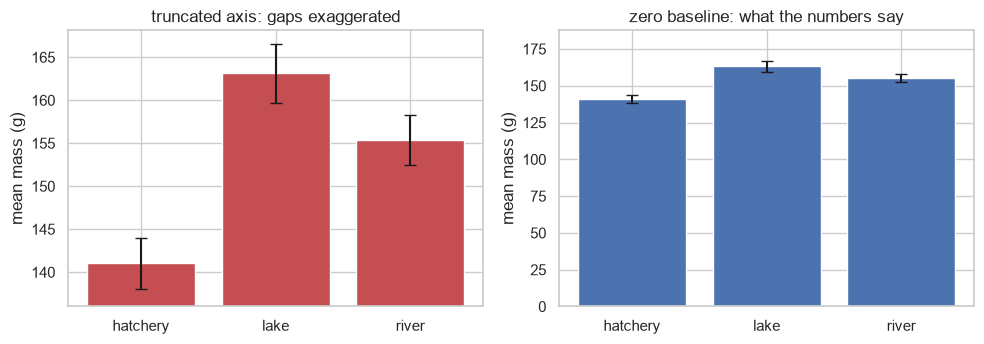

means: {'hatchery': 141.0, 'lake': 163.1, 'river': 155.4}
largest gap as a share of the smallest mean: 15.7%


In [9]:
means = clean.groupby("site").mass_g.mean()
errs = clean.groupby("site").mass_g.sem() * 1.96

fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))
axes[0].bar(means.index, means.values, yerr=errs.values, capsize=4, color="#C44E52")
axes[0].set_ylim(means.min() - 5, means.max() + 5)
axes[0].set_title("truncated axis: gaps exaggerated")

axes[1].bar(means.index, means.values, yerr=errs.values, capsize=4, color="#4C72B0")
axes[1].set_ylim(0, means.max() * 1.15)
axes[1].set_title("zero baseline: what the numbers say")
for ax in axes:
    ax.set_ylabel("mean mass (g)")
fig.tight_layout()
plt.show()

print("means:", means.round(1).to_dict())
print("largest gap as a share of the smallest mean:",
      f"{(means.max() - means.min()) / means.min():.1%}")

The site means really differ, but the truncated bar axis exaggerates their
relative sizes. A caption does not repair that length encoding: use the
zero-based bars on the right. The error bars here are **1.96 × SEM**, an
approximate 95% interval for a mean under an independence assumption, rather
than the ±1 SEM bars in the slides. A line chart encodes values by position
and can use a non-zero baseline when the scale and context are clear.

## Step 10: the findings note

The deliverable of the whole pass is a short written list, findings on the left
and what each one changes on the right. For this table:

| Finding | Consequence |
|---|---|
| one row per fish, 900 rows, five columns, 30 masses missing | model on 870 complete rows, or impute mass within site |
| four lengths recorded as 0.0 | a sensor fault, removed; keep the range check |
| length is a flat plateau, not one hump | three populations; site is a feature, not noise |
| mass per cm is about 9 g within every site, 3.6 g pooled | never report the pooled slope; fit within site or include site |
| sites differ in both length and mass | any comparison across sites must condition on site |
| bar charts of site means need a zero baseline | fix the axis limits before the figure leaves the notebook |

## What to take from this

- Phase 1 is prose, not a plot, and it is the phase people skip.
- The bin width and the axis limits are analytical choices. Change one, change
  the conclusion.
- Condition before you pool. If the groups differ in both variables, the pooled
  relationship is about the groups, not about the variables.
- Phase 4 turns "this looks fine" into assertions that fail visibly.
- Every figure you keep gets a caption naming what it does **not** show.
- The pass ends in a findings note, not in a folder of figures.

## Where to go next

- **Reading, Session 6**: the ten steps in full, the Titanic pass, and the
  catalogue of charts that mislead without being false.
- **Session 7**: where the findings note becomes a model's input, and where
  conditioning becomes a `ColumnTransformer`.